In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 624.7 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.0 MB/s eta 0:00:00a 0:00:01


In [9]:
from ultralytics import YOLO

import os

dataset_path = "/kaggle/input/datasets/reemmousa87/merged-dataset/merged_dataset"

for split in ["train", "val", "test"]:
    imgs = len(os.listdir(f"{dataset_path}/images/{split}"))
    labels = len(os.listdir(f"{dataset_path}/labels/{split}"))
    print(split, "Images:", imgs, "Labels:", labels)

train Images: 11302 Labels: 11302
val Images: 1413 Labels: 1413
test Images: 1413 Labels: 1413


In [10]:
yaml_path = "/kaggle/working/data.yaml"

yaml_content = """
path: /kaggle/input/datasets/reemmousa87/merged-dataset/merged_dataset

train: images/train
val: images/val
test: images/test

names:
  0: drone
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(open(yaml_path).read())


path: /kaggle/input/datasets/reemmousa87/merged-dataset/merged_dataset

train: images/train
val: images/val
test: images/test

names:
  0: drone



In [11]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

In [14]:
from pathlib import Path

label_dir = Path("/kaggle/input/datasets/reemmousa87/merged-dataset/merged_dataset/labels/train")

labels = list(label_dir.glob("*.txt"))

print("Number of labels:", len(labels))

print(labels[0].read_text())

Number of labels: 11302
0 0.3333333333333333 0.49907407407407406 0.06770833333333333 0.07222222222222222



In [16]:
results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=35,
    imgsz=640,
    batch=18,
    optimizer="AdamW",
    lr0=0.001,
    patience=8,
    device=[0, 1],
    workers=2,
    project="MergedDatasets_YOLO11m",
    verbose = True,
    name="exp1",
    save=True,
    plots=True
)

Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=18, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt

In [18]:
model = YOLO(
"/kaggle/working/runs/detect/MergedDatasets_YOLO11m/exp1-3/weights/best.pt"
)

metrics = model.val(
    data="/kaggle/working/data.yaml",
    split="test",
    plots=True
)

print(metrics)

Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 271.8±84.9 MB/s, size: 119.3 KB)
val: Scanning /kaggle/input/datasets/reemmousa87/merged-dataset/merged_dataset/labels/test... 1413 images, 34 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1413/1413 1.3Kit/s 1.1s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/reemmousa87/merged-dataset/merged_dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 2.9it/s 31.1s0.4ss
                   all       1413       1379       0.94      0.943      0.967      0.579
Speed: 0.6ms preprocess, 17.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_ind

In [19]:
import shutil

shutil.make_archive(
    "/kaggle/working/runs/detect",
    "zip",
    "/kaggle/working/runs/detect"
)

print("ZIP file created!")

ZIP file created!



0: 640x640 1 drone, 43.2ms
1: 640x640 1 drone, 43.2ms
2: 640x640 1 drone, 43.2ms
3: 640x640 1 drone, 43.2ms
4: 640x640 1 drone, 43.2ms
5: 640x640 1 drone, 43.2ms
Speed: 2.8ms preprocess, 43.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


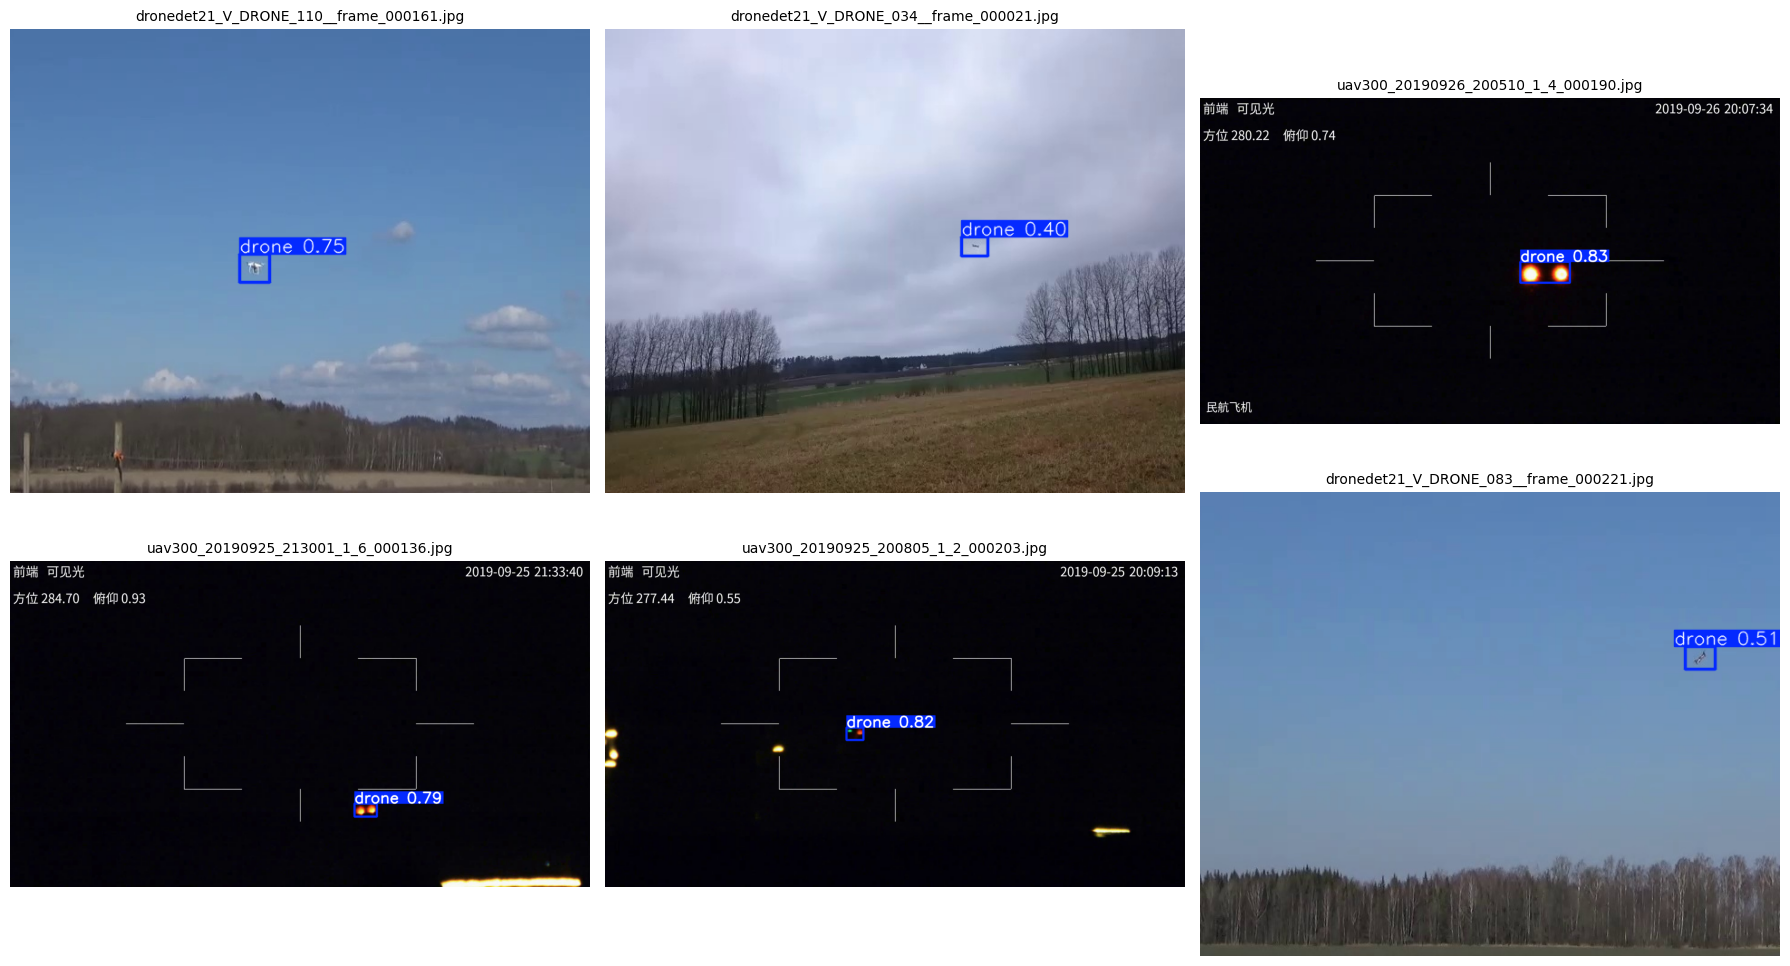

In [2]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt

model = YOLO(r"D:\DELL\Desktop\Drones_training_results\RESULTS\merged-datasets_YOLO11m\train_output\detect\MergedDatasets_YOLO11m\exp1-3\weights\best.pt")

test_dir = Path(r"D:\DELL\Desktop\Drones_training_results\Full_Dataset\merged_dataset\images\test")

image_files = list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.png"))

sample_images = random.sample(image_files, 6)

results = model.predict(
    source=[str(img) for img in sample_images],
    imgsz=640,
    conf=0.25,
    save=False,      # no need to save
    device=0
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, result, img_path in zip(axes, results, sample_images):
    annotated = result.plot()          # BGR image
    annotated = annotated[:, :, ::-1]  # Convert BGR → RGB

    ax.imshow(annotated)
    ax.set_title(img_path.name, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()